In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [11]:
sub_merged = pd.read_excel("../../data/processed/team/subway_merged_base.xlsx")
sub_merged['TOTAL_W'] = sub_merged['ES'] + sub_merged['EV']*4
sub_merged.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)
sub_merged.head()

,지하철역,호선명,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,TOTAL_W
0,제기동,1,1013099,559716,55.25,3,2,5,39979.71,14
1,종각,1,2195935,292689,13.33,4,2,6,16260.50,18
2,종로5가,1,1410815,488319,34.61,3,0,3,40693.25,12
3,청량리,1,1319724,561989,42.58,2,6,8,40142.07,14
4,강남,2,4549323,302191,6.64,4,0,4,18886.94,16


In [12]:
priorities = pd.read_csv("../../data/processed/team/priority_area.csv", encoding='cp949')
priorities.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)
priorities.head()

,지하철역,호선명,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,종로5가,1,1410815,488319,34.61,3,0,3,40693.25
1,청량리,1,1319724,561989,42.58,2,6,8,40142.07
2,제기동,1,1013099,559716,55.25,3,2,5,39979.71
3,미아사거리,4,1544727,380795,24.65,2,2,4,38079.50
4,상계,4,1096973,261592,23.85,1,4,5,32699.00


In [13]:
transfer = pd.read_excel("../../data/processed/team/transfer_merged_final.xlsx")
transfer_master = pd.merge(sub_merged, transfer[['지하철역', '호선', '환승노선', '환승거리', '환승소요시간']], on='지하철역', how='left')
transfer_master = transfer_master.sort_values(by='환승거리', ascending=False)
transfer_master.loc[transfer_master['지하철역']=='서울역', '지하철역'] = '서울'
transfer_master = transfer_master[~(transfer_master['지하철역']=='지축')]

transfer_station_list = transfer_master[transfer_master['호선명'].str.contains(",")]  #이렇게 하면 창동역이 빠짐
transfer_station_list = transfer_station_list['지하철역'].unique()
transfer_station_list

array(['고속터미널', '종로3가', '노원', '대림', '동작', '신당', '동대문역사문화공원', '충정로', '동대문',
       '잠실', '연신내', '이수', '신설동', '삼각지', '을지로3가', '약수', '영등포구청', '김포공항',
       '당산', '청구', '시청', '불광', '동묘앞', '왕십리', '합정', '을지로4가', '건대입구', '군자',
       '교대', '사당', '공덕', '여의도', '오금', '태릉입구', '천호', '가락시장', '충무로', '서울'],
      dtype=object)

In [14]:
lines_sep_merged = pd.read_excel("../../data/processed/team/lines_sep_merged.xlsx")
lines_sep_merged

,호선명,지하철역,전체승하차,무임승하차,무임승하차비중,노선분류,ES,EV,TOTAL_W,시설부하지수
0,1호선,동대문,718764,249909,34.77,old,1.0,3.0,13.0,19223.77
1,1호선,동묘앞,624723,316570,50.67,old,12.0,7.0,40.0,7914.25
2,1호선,서울역,3483172,445341,12.79,old,5.0,4.0,21.0,21206.71
3,1호선,시청,1523415,211955,13.91,old,3.0,3.0,15.0,14130.33
4,1호선,신설동,806734,237361,29.42,old,0.0,5.0,20.0,11868.05
...,...,...,...,...,...,...,...,...,...,...
284,9호선,양천향교,582088,98776,16.97,new,27.0,4.0,43.0,2297.12
285,9호선,여의도,1640398,107410,6.55,new,12.0,2.0,20.0,5370.50
286,9호선,염창,1004681,159211,15.85,new,12.0,4.0,28.0,5686.11
287,9호선,증미,428833,77371,18.04,new,18.0,3.0,30.0,2579.03


In [16]:
# 집중관리역에 포함되는 환승역 몇개인지? 
common_station = transfer_station_list[pd.Series(transfer_station_list).isin(priorities['지하철역'])]
common_station

array(['종로3가', '동대문', '잠실', '연신내', '을지로3가', '교대', '사당', '천호', '서울'],
      dtype=object)

In [18]:
# 집중관리구역 전체의 시설부하지수 평균
priorities['시설부하지수'].describe()

count       49.000000
mean     20018.121429
std       7680.678833
min      12372.720000
25%      13968.050000
50%      17877.080000
75%      22305.670000
max      40693.250000
Name: 시설부하지수, dtype: float64

In [19]:
transfer_master['환승여부'] = ""
transfer_master.loc[transfer_master['환승노선'].isna(), '환승여부'] = '비환승역'
transfer_master.loc[~transfer_master['환승노선'].isna(), '환승여부'] = '환승역'

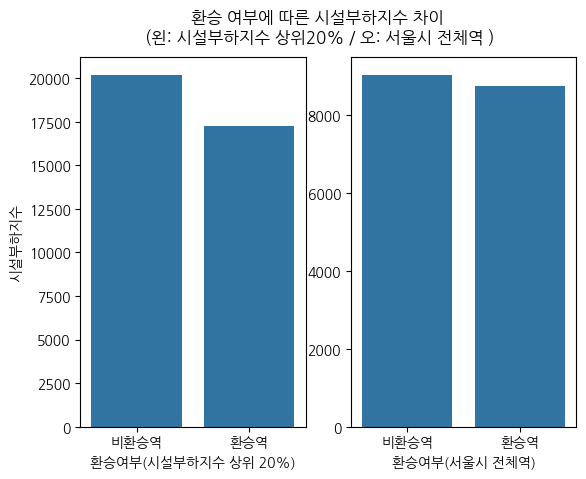

In [20]:
# 환승역 vs. 비환승역
priorities['환승여부'] = ''
priorities.loc[transfer_master['환승노선'].isna(), '환승여부'] = '비환승역'
priorities.loc[~transfer_master['환승노선'].isna(), '환승여부'] = '환승역'

fig, axes = plt.subplots(1, 2)
sns.barplot(data=priorities, x='환승여부', y='시설부하지수', errorbar=None, ax=axes[0])
sns.barplot(data=transfer_master, x='환승여부', y='시설부하지수', errorbar=None, ax=axes[1], order=['비환승역', '환승역'])
plt.suptitle("환승 여부에 따른 시설부하지수 차이 \n(왼: 시설부하지수 상위20% / 오: 서울시 전체역 )")
axes[1].set_ylabel("")
axes[0].set_xlabel("환승여부(시설부하지수 상위 20%)")
axes[1].set_xlabel("환승여부(서울시 전체역)")
plt.show()